# CPU vs GPU Trigonometric Precision Divergence Analysis

This notebook quantifies the floating-point precision differences between CPU (`Math.sin`/`Math.cos` truncated to `f32` via `Math.fround`) and GPU (native WGSL `f32` `sin`/`cos`) trigonometric implementations, using controlled agent-based simulations.

**Simulations:**
- `trig_basic` — Fixed-angle rotation each frame (angle = 0.7 rad)
- `trig_sweep` — Agent ID-indexed angle sweep (0.00–4.99 rad)
- `trig_sense` — Sensor-like rotation (angle = 0.6 rad)

**Methods compared:**
- JavaScript (CPU, reference)
- WebAssembly (CPU, control)
- WebWorkers (CPU, control)
- WebGPU (GPU, test subject)

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import struct
import os

sns.set_theme(style='whitegrid', context='paper', font_scale=1.2)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (10, 6)

OUTPUT_DIR = os.path.join('..', 'tests', 'compute', 'outputs')

def load_simulation(name):
    """Load positions_data.json for a simulation and return structured data."""
    path = os.path.join(OUTPUT_DIR, name, 'positions_data.json')
    with open(path) as f:
        raw = json.load(f)
    
    result = {
        'meta': {
            'simulation': raw['simulation'],
            'numFrames': raw['numFrames'],
            'numAgents': raw['numAgents'],
            'width': raw['width'],
            'height': raw['height'],
        }
    }
    
    for method_name, method_data in raw['methods'].items():
        if not method_data['available']:
            continue
        num_frames = len(method_data['frames'])
        num_agents = len(method_data['frames'][0]['agents'])
        
        x  = np.zeros((num_frames, num_agents), dtype=np.float64)
        y  = np.zeros((num_frames, num_agents), dtype=np.float64)
        vx = np.zeros((num_frames, num_agents), dtype=np.float64)
        vy = np.zeros((num_frames, num_agents), dtype=np.float64)
        ids = np.zeros(num_agents, dtype=np.int32)
        
        for fi, frame_data in enumerate(method_data['frames']):
            for ai, agent in enumerate(frame_data['agents']):
                x[fi, ai] = agent['x']
                y[fi, ai] = agent['y']
                vx[fi, ai] = agent['vx']
                vy[fi, ai] = agent['vy']
                if fi == 0:
                    ids[ai] = agent['id']
        
        result[method_name] = {'x': x, 'y': y, 'vx': vx, 'vy': vy, 'ids': ids}
    
    return result

def load_comparison_report(name):
    """Load comparison_report.json for a simulation."""
    path = os.path.join(OUTPUT_DIR, name, 'comparison_report.json')
    with open(path) as f:
        return json.load(f)

# Load all three trig simulations
trig_basic = load_simulation('trig_basic')
trig_sweep = load_simulation('trig_sweep')
trig_sense = load_simulation('trig_sense')

print('Loaded simulations:')
for name, data in [('trig_basic', trig_basic), ('trig_sweep', trig_sweep), ('trig_sense', trig_sense)]:
    meta = data['meta']
    methods = [k for k in data.keys() if k != 'meta']
    print(f'  {name}: {meta["numAgents"]} agents, {meta["numFrames"]} frames, methods: {methods}')

Loaded simulations:
  trig_basic: 500 agents, 100 frames, methods: ['JavaScript', 'WebAssembly', 'WebWorkers', 'WebGPU']
  trig_sweep: 500 agents, 100 frames, methods: ['JavaScript', 'WebAssembly', 'WebWorkers', 'WebGPU']
  trig_sense: 500 agents, 100 frames, methods: ['JavaScript', 'WebAssembly', 'WebWorkers', 'WebGPU']


## Section 2: Single-Operation Error (trig_sweep)

The `trig_sweep` simulation applies `turn(id * 0.01)` to each agent, sweeping angles from 0 to ~5 radians across 500 agents. After **one frame**, each agent's velocity encodes the result of `cos(angle)` and `sin(angle)` applied to the original velocity vector. By comparing GPU vs CPU results at frame 1, we isolate the **raw hardware-level sin/cos difference** without any accumulation.

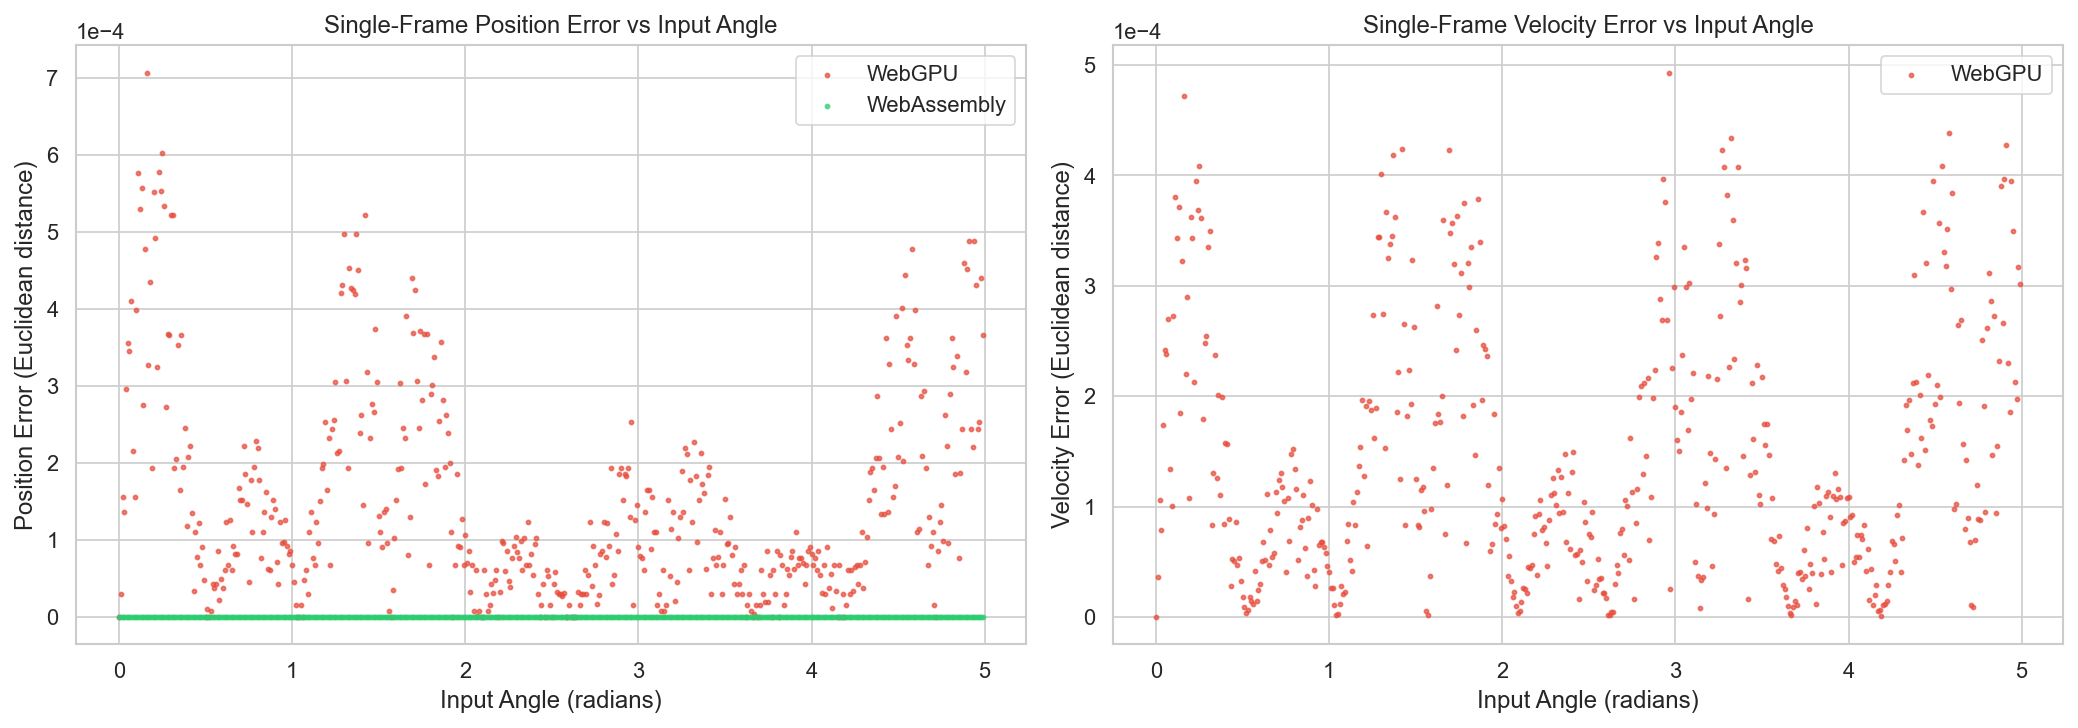


Single-Operation Error Statistics (Frame 1, trig_sweep):
  GPU Position Error — max: 7.07e-04, mean: 1.48e-04, std: 1.35e-04
  GPU Velocity Error — max: 4.93e-04, mean: 1.46e-04, std: 1.16e-04
  WASM Position Error — max: 0.00e+00, mean: 0.00e+00


In [4]:
# Frame 1 analysis for trig_sweep: GPU vs JS single-operation error
js = trig_sweep['JavaScript']
gpu = trig_sweep['WebGPU']
wasm = trig_sweep['WebAssembly']

# Angles for each agent
angles = js['ids'] * 0.01

# Position error at frame 1 (after one turn+moveForward)
frame = 1
dx_gpu = gpu['x'][frame] - js['x'][frame]
dy_gpu = gpu['y'][frame] - js['y'][frame]
pos_err_gpu = np.sqrt(dx_gpu**2 + dy_gpu**2)

dvx_gpu = gpu['vx'][frame] - js['vx'][frame]
dvy_gpu = gpu['vy'][frame] - js['vy'][frame]
vel_err_gpu = np.sqrt(dvx_gpu**2 + dvy_gpu**2)

# Same for WASM (control)
dx_wasm = wasm['x'][frame] - js['x'][frame]
dy_wasm = wasm['y'][frame] - js['y'][frame]
pos_err_wasm = np.sqrt(dx_wasm**2 + dy_wasm**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position error vs angle
axes[0].scatter(angles, pos_err_gpu, s=4, alpha=0.7, label='WebGPU', color='#e74c3c')
axes[0].scatter(angles, pos_err_wasm, s=4, alpha=0.7, label='WebAssembly', color='#2ecc71')
axes[0].set_xlabel('Input Angle (radians)')
axes[0].set_ylabel('Position Error (Euclidean distance)')
axes[0].set_title('Single-Frame Position Error vs Input Angle')
axes[0].legend()
axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Velocity error vs angle
axes[1].scatter(angles, vel_err_gpu, s=4, alpha=0.7, label='WebGPU', color='#e74c3c')
axes[1].set_xlabel('Input Angle (radians)')
axes[1].set_ylabel('Velocity Error (Euclidean distance)')
axes[1].set_title('Single-Frame Velocity Error vs Input Angle')
axes[1].legend()
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('fig_single_op_error_vs_angle.png', bbox_inches='tight')
plt.show()

# Statistics
print('\nSingle-Operation Error Statistics (Frame 1, trig_sweep):')
print(f'  GPU Position Error — max: {pos_err_gpu.max():.2e}, mean: {pos_err_gpu.mean():.2e}, std: {pos_err_gpu.std():.2e}')
print(f'  GPU Velocity Error — max: {vel_err_gpu.max():.2e}, mean: {vel_err_gpu.mean():.2e}, std: {vel_err_gpu.std():.2e}')
print(f'  WASM Position Error — max: {pos_err_wasm.max():.2e}, mean: {pos_err_wasm.mean():.2e}')

## Section 3: Error Accumulation Over Frames (trig_basic)

The `trig_basic` simulation applies `turn(0.7)` every frame to all agents. Since the same rotation is applied repeatedly, errors accumulate. This section plots how the GPU-CPU position difference grows over 100 frames and fits a linear regression to quantify the **error growth rate**.

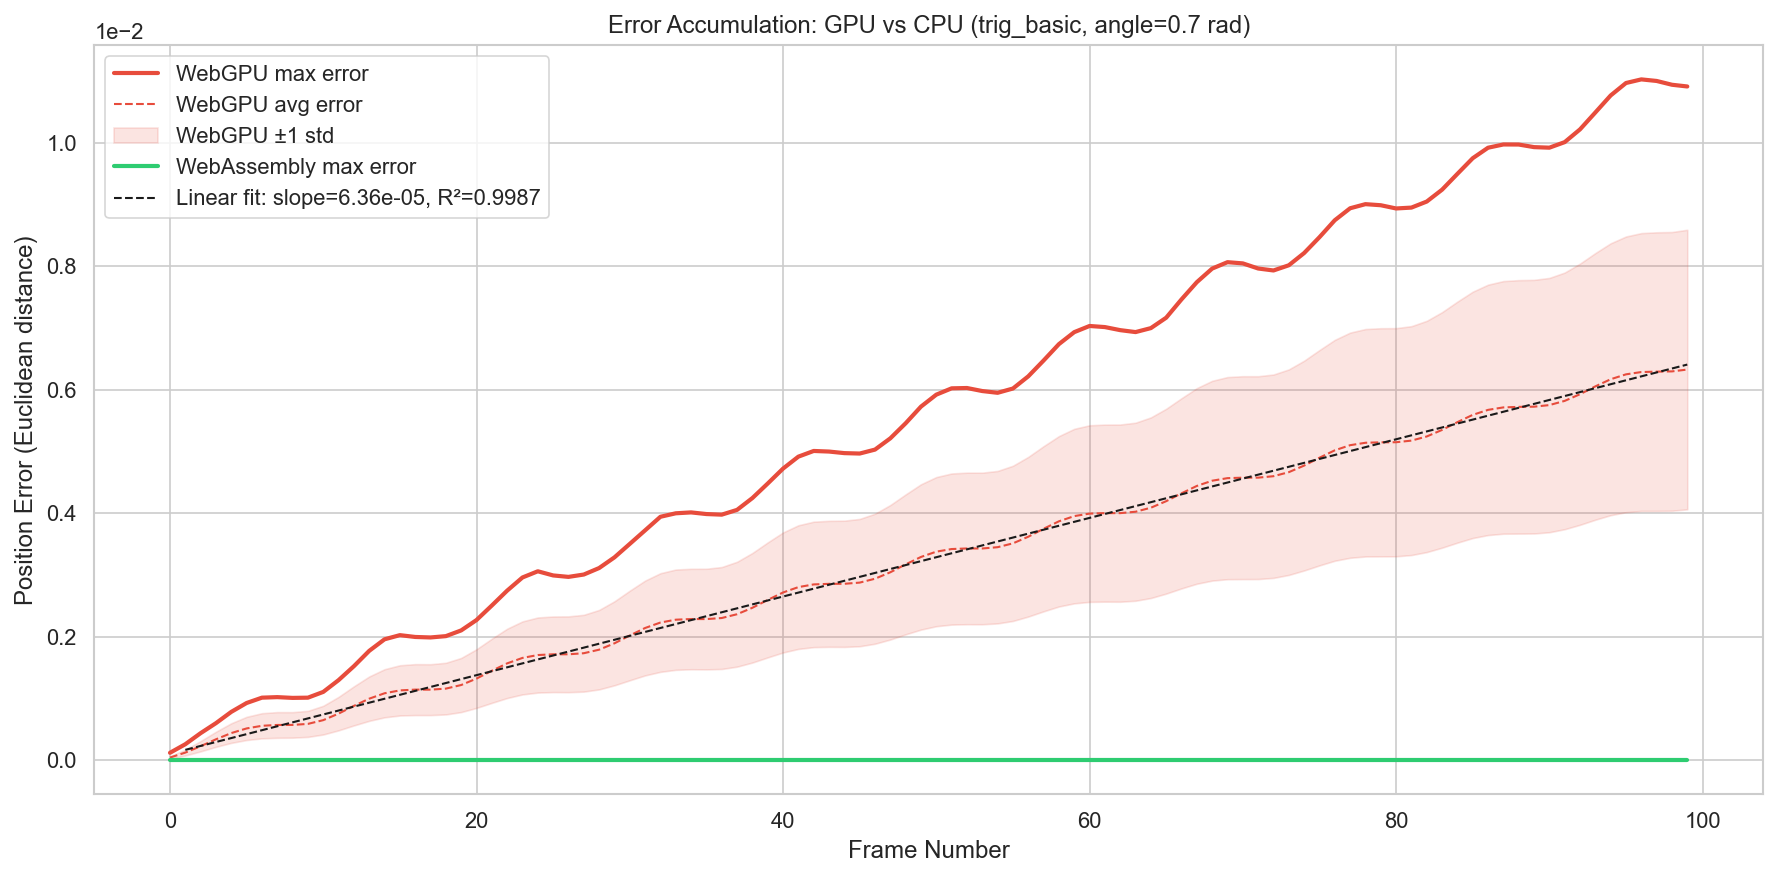


Linear regression on GPU avg position error:
  Slope (error/frame): 6.364622e-05
  Intercept: 1.058662e-04
  R²: 0.998689
  p-value: 1.28e-141

WebAssembly max error at final frame: 0.00e+00 (expected ~0)


In [5]:
# Error accumulation: trig_basic
js = trig_basic['JavaScript']
gpu = trig_basic['WebGPU']
wasm = trig_basic['WebAssembly']
num_frames = trig_basic['meta']['numFrames']

frames = np.arange(num_frames)

# Per-frame error statistics
gpu_max_err = np.zeros(num_frames)
gpu_avg_err = np.zeros(num_frames)
gpu_std_err = np.zeros(num_frames)
wasm_max_err = np.zeros(num_frames)
wasm_avg_err = np.zeros(num_frames)

for f in range(num_frames):
    dx = gpu['x'][f] - js['x'][f]
    dy = gpu['y'][f] - js['y'][f]
    err = np.sqrt(dx**2 + dy**2)
    gpu_max_err[f] = err.max()
    gpu_avg_err[f] = err.mean()
    gpu_std_err[f] = err.std()
    
    dx_w = wasm['x'][f] - js['x'][f]
    dy_w = wasm['y'][f] - js['y'][f]
    err_w = np.sqrt(dx_w**2 + dy_w**2)
    wasm_max_err[f] = err_w.max()
    wasm_avg_err[f] = err_w.mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(frames, gpu_max_err, label='WebGPU max error', color='#e74c3c', linewidth=2)
ax.plot(frames, gpu_avg_err, label='WebGPU avg error', color='#e74c3c', linewidth=1, linestyle='--')
ax.fill_between(frames, gpu_avg_err - gpu_std_err, gpu_avg_err + gpu_std_err,
                alpha=0.15, color='#e74c3c', label='WebGPU ±1 std')
ax.plot(frames, wasm_max_err, label='WebAssembly max error', color='#2ecc71', linewidth=2)

# Linear regression on GPU avg error (skip frame 0)
mask = frames > 0
slope, intercept, r_value, p_value, std_err = stats.linregress(frames[mask], gpu_avg_err[mask])
ax.plot(frames[mask], intercept + slope * frames[mask], 'k--', linewidth=1,
        label=f'Linear fit: slope={slope:.2e}, R²={r_value**2:.4f}')

ax.set_xlabel('Frame Number')
ax.set_ylabel('Position Error (Euclidean distance)')
ax.set_title('Error Accumulation: GPU vs CPU (trig_basic, angle=0.7 rad)')
ax.legend(loc='upper left')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('fig_error_accumulation.png', bbox_inches='tight')
plt.show()

print(f'\nLinear regression on GPU avg position error:')
print(f'  Slope (error/frame): {slope:.6e}')
print(f'  Intercept: {intercept:.6e}')
print(f'  R²: {r_value**2:.6f}')
print(f'  p-value: {p_value:.2e}')
print(f'\nWebAssembly max error at final frame: {wasm_max_err[-1]:.2e} (expected ~0)')

## Section 4: Velocity Vector Analysis

Since the `turn` command directly modifies `vx` and `vy` via sin/cos, velocity error is the most direct measure of trigonometric precision. This section separates the error into:
- **Angular error**: difference in the direction of the velocity vector
- **Magnitude error**: difference in speed

This distinguishes whether the GPU divergence is primarily in **direction** (angle) or **speed** (magnitude).

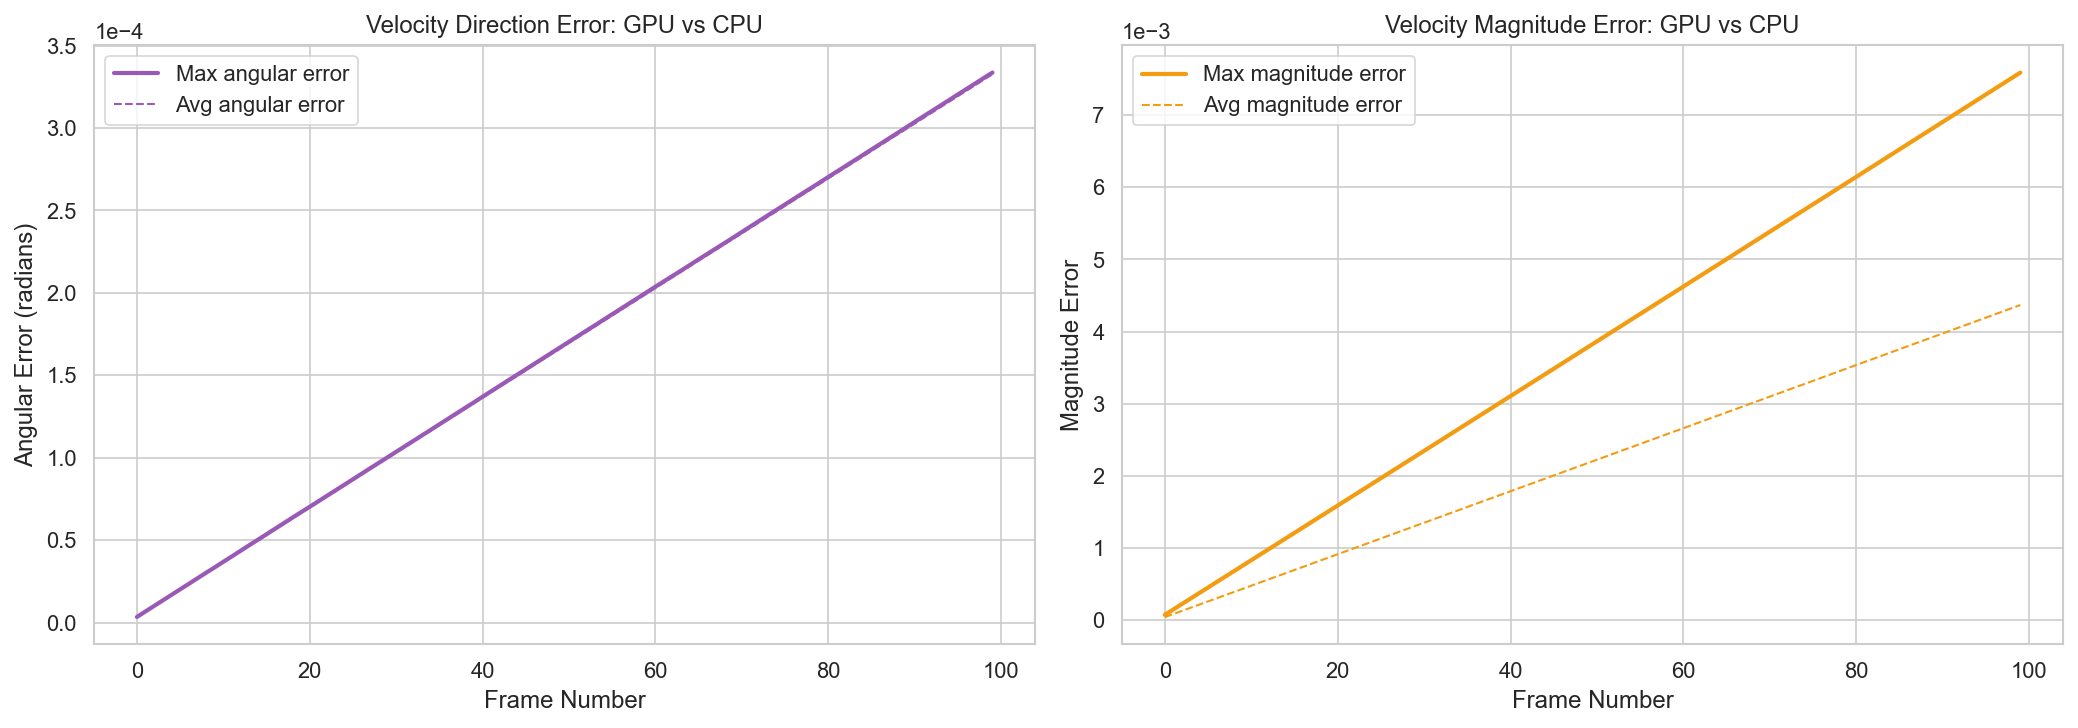


Velocity Analysis (trig_basic, final frame):
  Angular error — max: 3.336510e-04 rad, avg: 3.326677e-04 rad
  Magnitude error — max: 7.587634e-03, avg: 4.367487e-03


In [6]:
# Velocity vector analysis: trig_basic
js = trig_basic['JavaScript']
gpu = trig_basic['WebGPU']
num_frames = trig_basic['meta']['numFrames']
frames = np.arange(num_frames)

# Angular and magnitude errors per frame
ang_err_max = np.zeros(num_frames)
ang_err_avg = np.zeros(num_frames)
mag_err_max = np.zeros(num_frames)
mag_err_avg = np.zeros(num_frames)

for f in range(num_frames):
    # Angles
    theta_js = np.arctan2(js['vy'][f], js['vx'][f])
    theta_gpu = np.arctan2(gpu['vy'][f], gpu['vx'][f])
    
    # Wrapped angular difference
    ang_diff = np.abs(np.arctan2(np.sin(theta_gpu - theta_js), np.cos(theta_gpu - theta_js)))
    ang_err_max[f] = ang_diff.max()
    ang_err_avg[f] = ang_diff.mean()
    
    # Magnitude difference
    mag_js = np.sqrt(js['vx'][f]**2 + js['vy'][f]**2)
    mag_gpu = np.sqrt(gpu['vx'][f]**2 + gpu['vy'][f]**2)
    mag_diff = np.abs(mag_gpu - mag_js)
    mag_err_max[f] = mag_diff.max()
    mag_err_avg[f] = mag_diff.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Angular error
axes[0].plot(frames, ang_err_max, label='Max angular error', color='#9b59b6', linewidth=2)
axes[0].plot(frames, ang_err_avg, label='Avg angular error', color='#9b59b6', linewidth=1, linestyle='--')
axes[0].set_xlabel('Frame Number')
axes[0].set_ylabel('Angular Error (radians)')
axes[0].set_title('Velocity Direction Error: GPU vs CPU')
axes[0].legend()
axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Magnitude error
axes[1].plot(frames, mag_err_max, label='Max magnitude error', color='#f39c12', linewidth=2)
axes[1].plot(frames, mag_err_avg, label='Avg magnitude error', color='#f39c12', linewidth=1, linestyle='--')
axes[1].set_xlabel('Frame Number')
axes[1].set_ylabel('Magnitude Error')
axes[1].set_title('Velocity Magnitude Error: GPU vs CPU')
axes[1].legend()
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('fig_velocity_analysis.png', bbox_inches='tight')
plt.show()

print('\nVelocity Analysis (trig_basic, final frame):')
print(f'  Angular error — max: {ang_err_max[-1]:.6e} rad, avg: {ang_err_avg[-1]:.6e} rad')
print(f'  Magnitude error — max: {mag_err_max[-1]:.6e}, avg: {mag_err_avg[-1]:.6e}')

## Section 5: ULP (Units in Last Place) Analysis

The ULP is the standard metric for floating-point precision analysis. For each agent in `trig_sweep` at frame 1, we compute the f32-exact expected sin/cos values and measure the GPU deviation in ULP. This quantifies the **hardware-level precision** of the GPU's trigonometric unit.

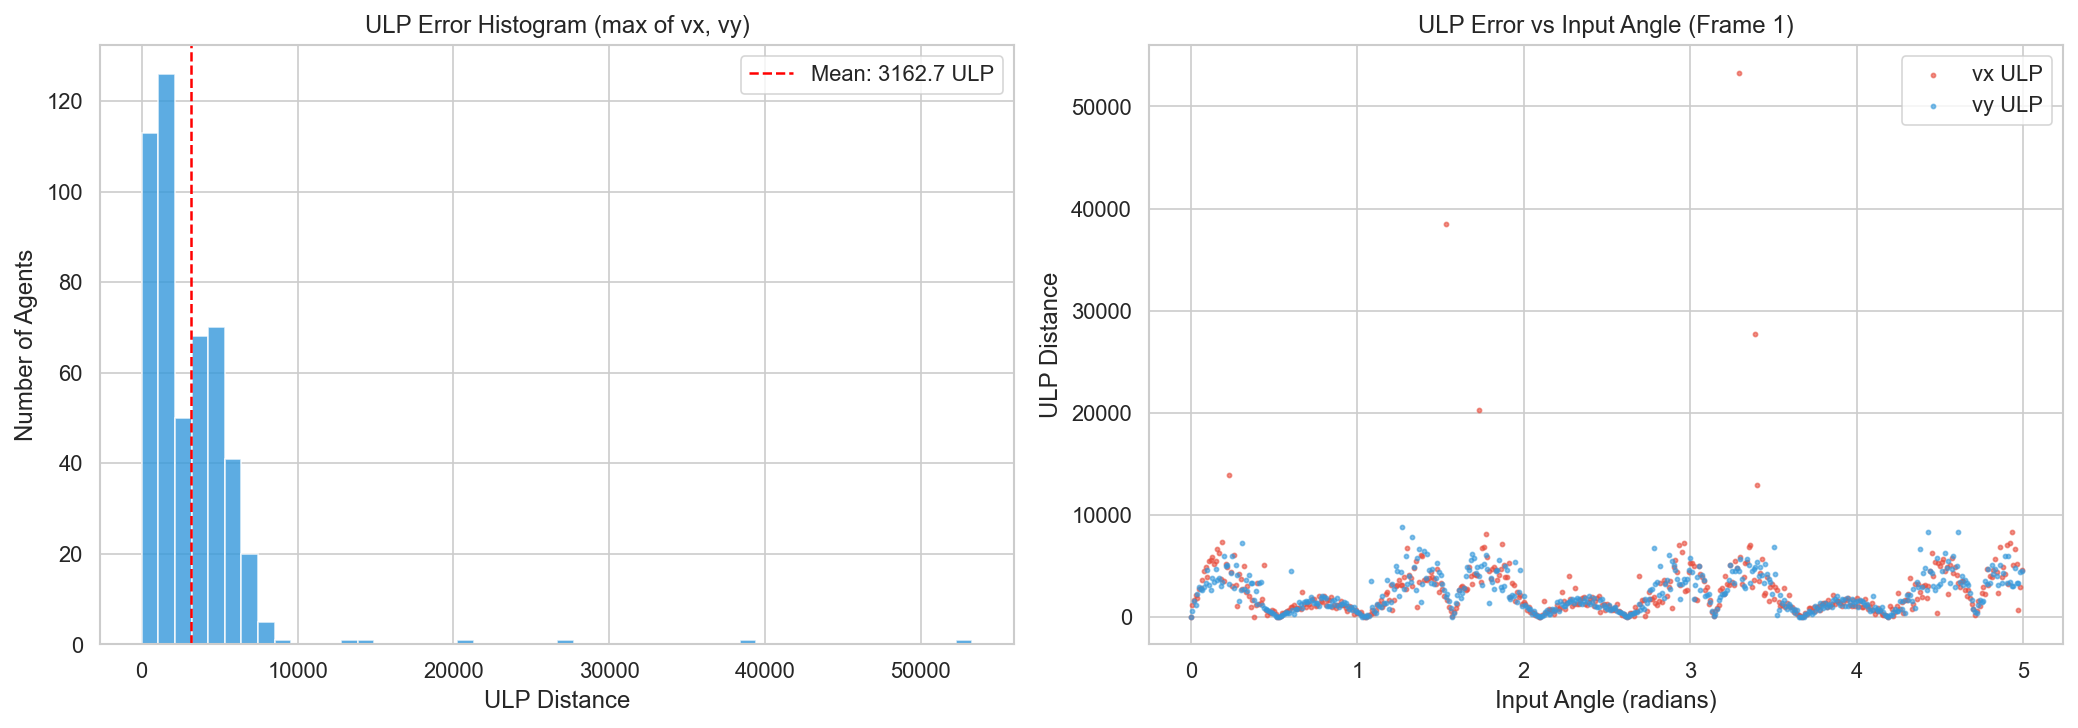


ULP Analysis (trig_sweep, frame 1):
  Max ULP (vx): 53312
  Max ULP (vy): 8856
  Max ULP (combined): 53312
  Mean ULP (combined): 3162.67
  Agents with 0 ULP error: 1 / 500
  Agents with >1 ULP error: 499 / 500


In [7]:
def float32_to_int_bits(f):
    """Convert a float32 value to its integer bit representation."""
    return struct.unpack('!I', struct.pack('!f', f))[0]

def ulp_distance(a, b):
    """Compute ULP distance between two float32 values."""
    a_f32 = np.float32(a)
    b_f32 = np.float32(b)
    a_bits = float32_to_int_bits(a_f32)
    b_bits = float32_to_int_bits(b_f32)
    # Handle sign differences
    if a_f32 < 0:
        a_bits = 0x80000000 - a_bits if a_bits != 0x80000000 else 0
    if b_f32 < 0:
        b_bits = 0x80000000 - b_bits if b_bits != 0x80000000 else 0
    return abs(int(a_bits) - int(b_bits))

# trig_sweep frame 1: compare GPU velocity components to JS (f32 reference)
js = trig_sweep['JavaScript']
gpu = trig_sweep['WebGPU']
angles = js['ids'] * 0.01

frame = 1
num_agents = len(angles)

ulp_vx = np.zeros(num_agents, dtype=np.int64)
ulp_vy = np.zeros(num_agents, dtype=np.int64)

for i in range(num_agents):
    ulp_vx[i] = ulp_distance(js['vx'][frame][i], gpu['vx'][frame][i])
    ulp_vy[i] = ulp_distance(js['vy'][frame][i], gpu['vy'][frame][i])

ulp_combined = np.maximum(ulp_vx, ulp_vy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ULP histogram
max_ulp = max(ulp_combined.max(), 1)
bins = np.arange(0, max_ulp + 2) - 0.5
if len(bins) > 50:
    bins = 50
axes[0].hist(ulp_combined, bins=bins, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('ULP Distance')
axes[0].set_ylabel('Number of Agents')
axes[0].set_title('ULP Error Histogram (max of vx, vy)')
axes[0].axvline(ulp_combined.mean(), color='red', linestyle='--', label=f'Mean: {ulp_combined.mean():.1f} ULP')
axes[0].legend()

# ULP vs angle
axes[1].scatter(angles, ulp_vx, s=4, alpha=0.6, label='vx ULP', color='#e74c3c')
axes[1].scatter(angles, ulp_vy, s=4, alpha=0.6, label='vy ULP', color='#3498db')
axes[1].set_xlabel('Input Angle (radians)')
axes[1].set_ylabel('ULP Distance')
axes[1].set_title('ULP Error vs Input Angle (Frame 1)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_ulp_analysis.png', bbox_inches='tight')
plt.show()

print('\nULP Analysis (trig_sweep, frame 1):')
print(f'  Max ULP (vx): {ulp_vx.max()}')
print(f'  Max ULP (vy): {ulp_vy.max()}')
print(f'  Max ULP (combined): {ulp_combined.max()}')
print(f'  Mean ULP (combined): {ulp_combined.mean():.2f}')
print(f'  Agents with 0 ULP error: {(ulp_combined == 0).sum()} / {num_agents}')
print(f'  Agents with >1 ULP error: {(ulp_combined > 1).sum()} / {num_agents}')

## Section 6: Statistical Summary Table

A consolidated table suitable for inclusion in a research paper, summarizing error characteristics across all simulations and method pairs.

In [8]:
# Build summary table
rows = []

for sim_name, sim_data in [('trig_basic', trig_basic), ('trig_sweep', trig_sweep), ('trig_sense', trig_sense)]:
    js_data = sim_data['JavaScript']
    num_frames = sim_data['meta']['numFrames']
    frames_arr = np.arange(num_frames)
    
    for method in ['WebGPU', 'WebAssembly', 'WebWorkers']:
        if method not in sim_data:
            continue
        m_data = sim_data[method]
        
        # Compute per-frame position errors
        frame_avg_errs = np.zeros(num_frames)
        frame_max_errs = np.zeros(num_frames)
        
        for f in range(num_frames):
            dx = m_data['x'][f] - js_data['x'][f]
            dy = m_data['y'][f] - js_data['y'][f]
            err = np.sqrt(dx**2 + dy**2)
            frame_avg_errs[f] = err.mean()
            frame_max_errs[f] = err.max()
        
        # Linear fit for error growth rate
        mask = frames_arr > 0
        if frame_avg_errs[mask].max() > 0:
            slope, _, r2, _, _ = stats.linregress(frames_arr[mask], frame_avg_errs[mask])
        else:
            slope, r2 = 0.0, 1.0
        
        # ULP (frame 1 velocity)
        max_ulp = 0
        if num_frames > 1:
            for i in range(sim_data['meta']['numAgents']):
                u_vx = ulp_distance(js_data['vx'][1][i], m_data['vx'][1][i])
                u_vy = ulp_distance(js_data['vy'][1][i], m_data['vy'][1][i])
                max_ulp = max(max_ulp, u_vx, u_vy)
        
        rows.append({
            'Simulation': sim_name,
            'Method Pair': f'{method} vs JS',
            'Frames': num_frames,
            'Mean Pos Error': f'{frame_avg_errs.mean():.2e}',
            'Max Pos Error': f'{frame_max_errs.max():.2e}',
            'Error Growth (per frame)': f'{slope:.2e}',
            'Growth R²': f'{r2:.4f}' if slope > 0 else '—',
            'Max ULP (frame 1)': max_ulp,
        })

summary_df = pd.DataFrame(rows)
print('\n' + '='*100)
print('STATISTICAL SUMMARY TABLE')
print('='*100)
display(summary_df)

# Also save as LaTeX for paper inclusion
latex_str = summary_df.to_latex(index=False, caption='CPU vs GPU trigonometric precision divergence summary.',
                                 label='tab:trig_divergence')
print('\nLaTeX output:')
print(latex_str)


STATISTICAL SUMMARY TABLE


,Simulation,Method Pair,Frames,Mean Pos Error,Max Pos Error,Error Growth (per frame),Growth R²,Max ULP (frame 1)
0,trig_basic,WebGPU vs JS,100,3.26e-03,1.10e-02,6.36e-05,0.9993,15744
1,trig_basic,WebAssembly vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0
2,trig_basic,WebWorkers vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0
3,trig_sweep,WebGPU vs JS,100,1.77e-02,6.00e+02,5.49e-04,0.1304,53312
4,trig_sweep,WebAssembly vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0
5,trig_sweep,WebWorkers vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0
6,trig_sense,WebGPU vs JS,100,4.27e-03,1.48e-02,8.33e-05,0.9991,64768
7,trig_sense,WebAssembly vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0
8,trig_sense,WebWorkers vs JS,100,0.00e+00,0.00e+00,0.00e+00,—,0



LaTeX output:
\begin{table}
\caption{CPU vs GPU trigonometric precision divergence summary.}
\label{tab:trig_divergence}
\begin{tabular}{llrllllr}
\toprule
Simulation & Method Pair & Frames & Mean Pos Error & Max Pos Error & Error Growth (per frame) & Growth R² & Max ULP (frame 1) \\
\midrule
trig_basic & WebGPU vs JS & 100 & 3.26e-03 & 1.10e-02 & 6.36e-05 & 0.9993 & 15744 \\
trig_basic & WebAssembly vs JS & 100 & 0.00e+00 & 0.00e+00 & 0.00e+00 & — & 0 \\
trig_basic & WebWorkers vs JS & 100 & 0.00e+00 & 0.00e+00 & 0.00e+00 & — & 0 \\
trig_sweep & WebGPU vs JS & 100 & 1.77e-02 & 6.00e+02 & 5.49e-04 & 0.1304 & 53312 \\
trig_sweep & WebAssembly vs JS & 100 & 0.00e+00 & 0.00e+00 & 0.00e+00 & — & 0 \\
trig_sweep & WebWorkers vs JS & 100 & 0.00e+00 & 0.00e+00 & 0.00e+00 & — & 0 \\
trig_sense & WebGPU vs JS & 100 & 4.27e-03 & 1.48e-02 & 8.33e-05 & 0.9991 & 64768 \\
trig_sense & WebAssembly vs JS & 100 & 0.00e+00 & 0.00e+00 & 0.00e+00 & — & 0 \\
trig_sense & WebWorkers vs JS & 100 & 0.00e+00 

## Section 7: Comparison with WebAssembly (Control)

WebAssembly runs on the CPU and uses the same `Math.fround(Math.sin(...))` / `Math.fround(Math.cos(...))` pattern as JavaScript (imported functions from the JS host). If our compilation pipeline introduces no errors, WebAssembly should produce **exactly identical results** to JavaScript. This section validates that divergence is exclusively a GPU hardware phenomenon.

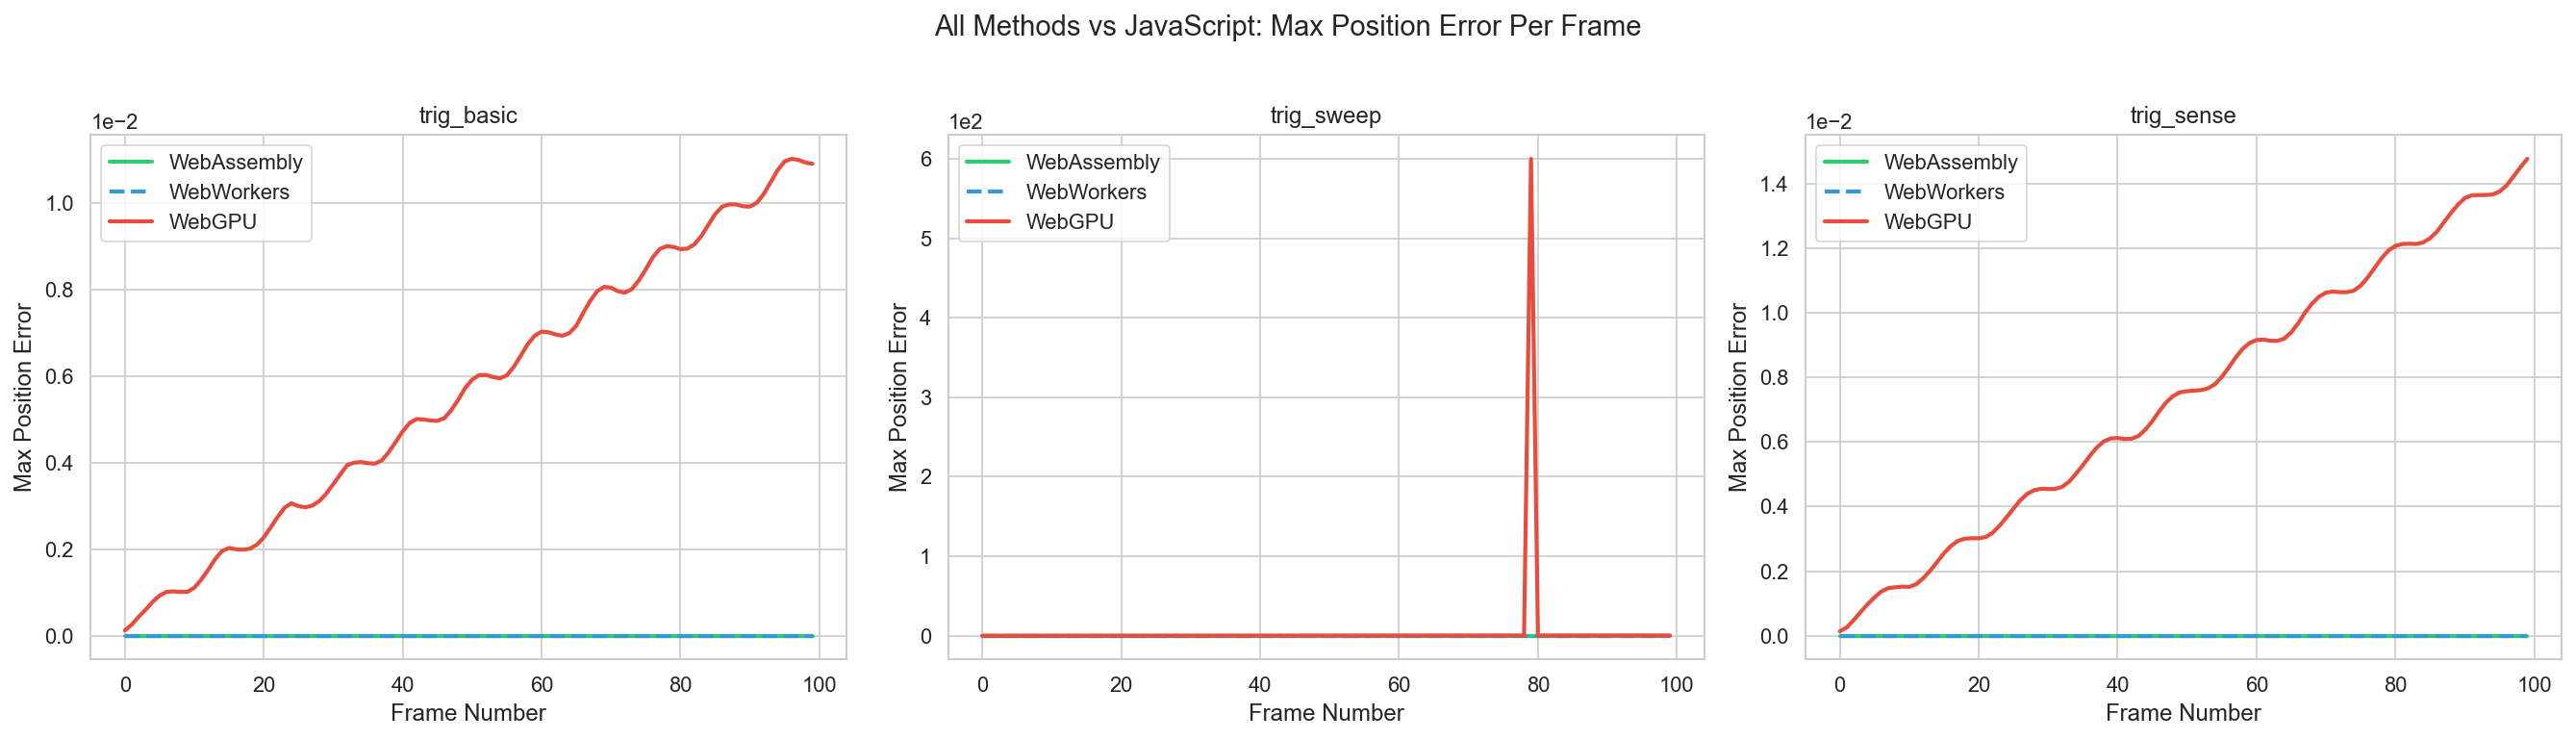


Control Validation: CPU methods vs JavaScript (should be exactly 0):
  trig_basic — WebAssembly: total cumulative error = 0.00e+00
  trig_basic — WebWorkers: total cumulative error = 0.00e+00
  trig_sweep — WebAssembly: total cumulative error = 0.00e+00
  trig_sweep — WebWorkers: total cumulative error = 0.00e+00
  trig_sense — WebAssembly: total cumulative error = 0.00e+00
  trig_sense — WebWorkers: total cumulative error = 0.00e+00


In [9]:
# Control: WebAssembly and WebWorkers vs JavaScript
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (sim_name, sim_data) in enumerate([('trig_basic', trig_basic), ('trig_sweep', trig_sweep), ('trig_sense', trig_sense)]):
    js_data = sim_data['JavaScript']
    num_frames = sim_data['meta']['numFrames']
    frames_arr = np.arange(num_frames)
    
    for method, color, ls in [('WebAssembly', '#2ecc71', '-'), ('WebWorkers', '#3498db', '--'), ('WebGPU', '#e74c3c', '-')]:
        if method not in sim_data:
            continue
        m_data = sim_data[method]
        max_errs = np.zeros(num_frames)
        for f in range(num_frames):
            dx = m_data['x'][f] - js_data['x'][f]
            dy = m_data['y'][f] - js_data['y'][f]
            max_errs[f] = np.sqrt(dx**2 + dy**2).max()
        axes[idx].plot(frames_arr, max_errs, label=method, color=color, linestyle=ls, linewidth=2)
    
    axes[idx].set_xlabel('Frame Number')
    axes[idx].set_ylabel('Max Position Error')
    axes[idx].set_title(f'{sim_name}')
    axes[idx].legend()
    axes[idx].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

fig.suptitle('All Methods vs JavaScript: Max Position Error Per Frame', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_control_comparison.png', bbox_inches='tight')
plt.show()

# Print control validation
print('\nControl Validation: CPU methods vs JavaScript (should be exactly 0):')
for sim_name, sim_data in [('trig_basic', trig_basic), ('trig_sweep', trig_sweep), ('trig_sense', trig_sense)]:
    js_data = sim_data['JavaScript']
    for method in ['WebAssembly', 'WebWorkers']:
        if method not in sim_data:
            continue
        m_data = sim_data[method]
        total_err = 0.0
        for f in range(sim_data['meta']['numFrames']):
            dx = m_data['x'][f] - js_data['x'][f]
            dy = m_data['y'][f] - js_data['y'][f]
            total_err += np.sqrt(dx**2 + dy**2).sum()
        print(f'  {sim_name} — {method}: total cumulative error = {total_err:.2e}')

## Section 8: Detailed Per-Agent Error Heatmap (trig_sweep)

Visualize how error evolves for each agent (angle) over frames.

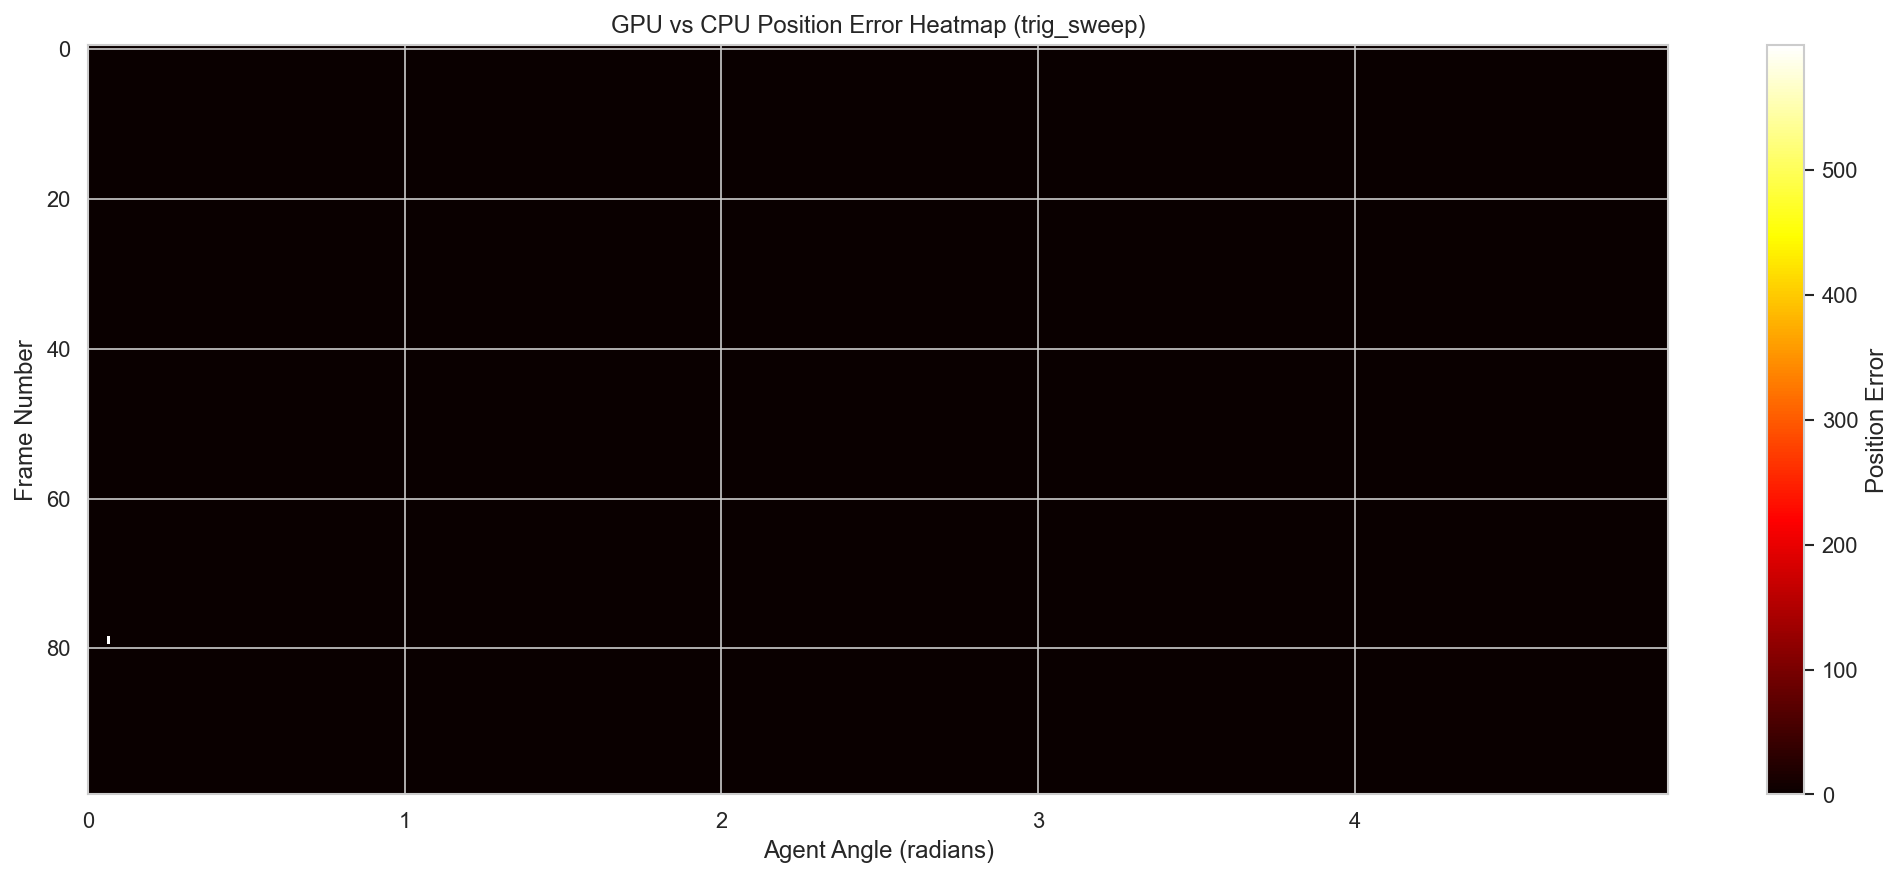


Top 5 angles with highest error at final frame:
  Agent 5, angle=0.0500 rad, error=2.900512e-01
  Agent 4, angle=0.0400 rad, error=2.747499e-01
  Agent 2, angle=0.0200 rad, error=2.394328e-01
  Agent 6, angle=0.0600 rad, error=2.072780e-01
  Agent 11, angle=0.1100 rad, error=1.884260e-01


In [10]:
# Per-agent error heatmap: trig_sweep
js = trig_sweep['JavaScript']
gpu = trig_sweep['WebGPU']
num_frames = trig_sweep['meta']['numFrames']
num_agents = trig_sweep['meta']['numAgents']
angles = js['ids'] * 0.01

error_matrix = np.zeros((num_frames, num_agents))
for f in range(num_frames):
    dx = gpu['x'][f] - js['x'][f]
    dy = gpu['y'][f] - js['y'][f]
    error_matrix[f] = np.sqrt(dx**2 + dy**2)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(error_matrix, aspect='auto', cmap='hot',
               extent=[angles[0], angles[-1], num_frames - 0.5, -0.5],
               interpolation='nearest')
ax.set_xlabel('Agent Angle (radians)')
ax.set_ylabel('Frame Number')
ax.set_title('GPU vs CPU Position Error Heatmap (trig_sweep)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Position Error')

plt.tight_layout()
plt.savefig('fig_error_heatmap.png', bbox_inches='tight')
plt.show()

# Identify angles with highest error
final_frame_err = error_matrix[-1]
top_5_idx = np.argsort(final_frame_err)[-5:][::-1]
print('\nTop 5 angles with highest error at final frame:')
for i in top_5_idx:
    print(f'  Agent {int(js["ids"][i])}, angle={angles[i]:.4f} rad, error={final_frame_err[i]:.6e}')